Section 7: Director Analysis

Questions:

Which director has the most titles?

How many unique directors are there?

Which directors appear only once?

In [1]:
import pandas as pd
data=pd.read_csv("../data/NetFlix.csv")
data.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...


In [2]:
data.director.value_counts().head(1)
data.director.str.split(",").explode().str.strip().nunique()
i=data.director.value_counts()
only_once=i[i==1].index
data.director[data.director.isin(only_once)]
data[data.director.isin(data.director.value_counts()[lambda x: x == 1].index)]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
8,s1005,Movie,BluffMaster!,Rohan Sippy,"Abhishek Bachchan, Priyanka Chopra, Riteish De...",India,8-Jan-21,2005,TV-14,129,"Comedies, International Movies, Romantic Movies",When his girlfriend learns the truth about his...
18,s1014,Movie,Bob's Broken Sleigh,Jay Surridge,"Cole Howard, Bruce Greenwood, Victor Garber, M...",Canada,17-Dec-15,2015,TV-G,47,Children & Family Movies,"An overly eager elf improves Santa's sleigh, b..."
...,...,...,...,...,...,...,...,...,...,...,...,...
7774,s988,Movie,Blood Money,Vishal Mahadkar,"Manish Chaudhary, Kunal Kemmu, Amrita Puri, Sh...",India,5-Jul-20,2012,TV-14,110,"Dramas, International Movies, Romantic Movies",Ambitious Kunal takes a job in the diamond bus...
7776,s99,Movie,3 Generations,Gaby Dellal,"Elle Fanning, Naomi Watts, Susan Sarandon, Tat...",United States,28-Aug-17,2015,PG-13,92,"Dramas, LGBTQ Movies",When teenage Ray begins transitioning from fem...
7778,s991,Movie,Blood Will Tell,"Miguel Cohan, Miguel Cohan","Oscar Martínez, Dolores Fonzi, Diego Velázquez...","Argentina, United States",21-Jun-19,2019,TV-MA,113,"Dramas, Independent Movies, International Movies",Family patriarch Elías begins to unravel after...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."


Section 8: Cast Analysis

Questions:

Which actor appears most often?

Which actors frequently collaborate?

Average cast size?

In [3]:
data.cast.str.split(",").explode().str.strip().value_counts().head(1)
# data.cast.str.split(",").explode().str.strip().value_counts().head(10).plot(kind="pie",figsize=(20,10))
data.cast.str.split(",").explode().str.strip().value_counts().nunique()
data.cast.value_counts().shape

from itertools import combinations
from collections import Counter

collab = Counter()
for cast in data.cast.dropna():
    actors=[actor.strip() for actor in cast.split(",")]
    collab.update(combinations(sorted(actors),2))
collab.most_common(5)

(data.cast.dropna().str.split(",").explode().size)/(data.cast.dropna().shape[0])
data["cast"].dropna().str.split(",").str.len().mean()




np.float64(7.915546753430471)

Section 9: Bivariate Analysis

These are much stronger than simple counts.

Examples:

Movies vs TV Shows across years

Country vs Genre

Country vs Rating

Genre vs Rating

Director vs Genre

Year vs Type

<Axes: xlabel='release_year'>

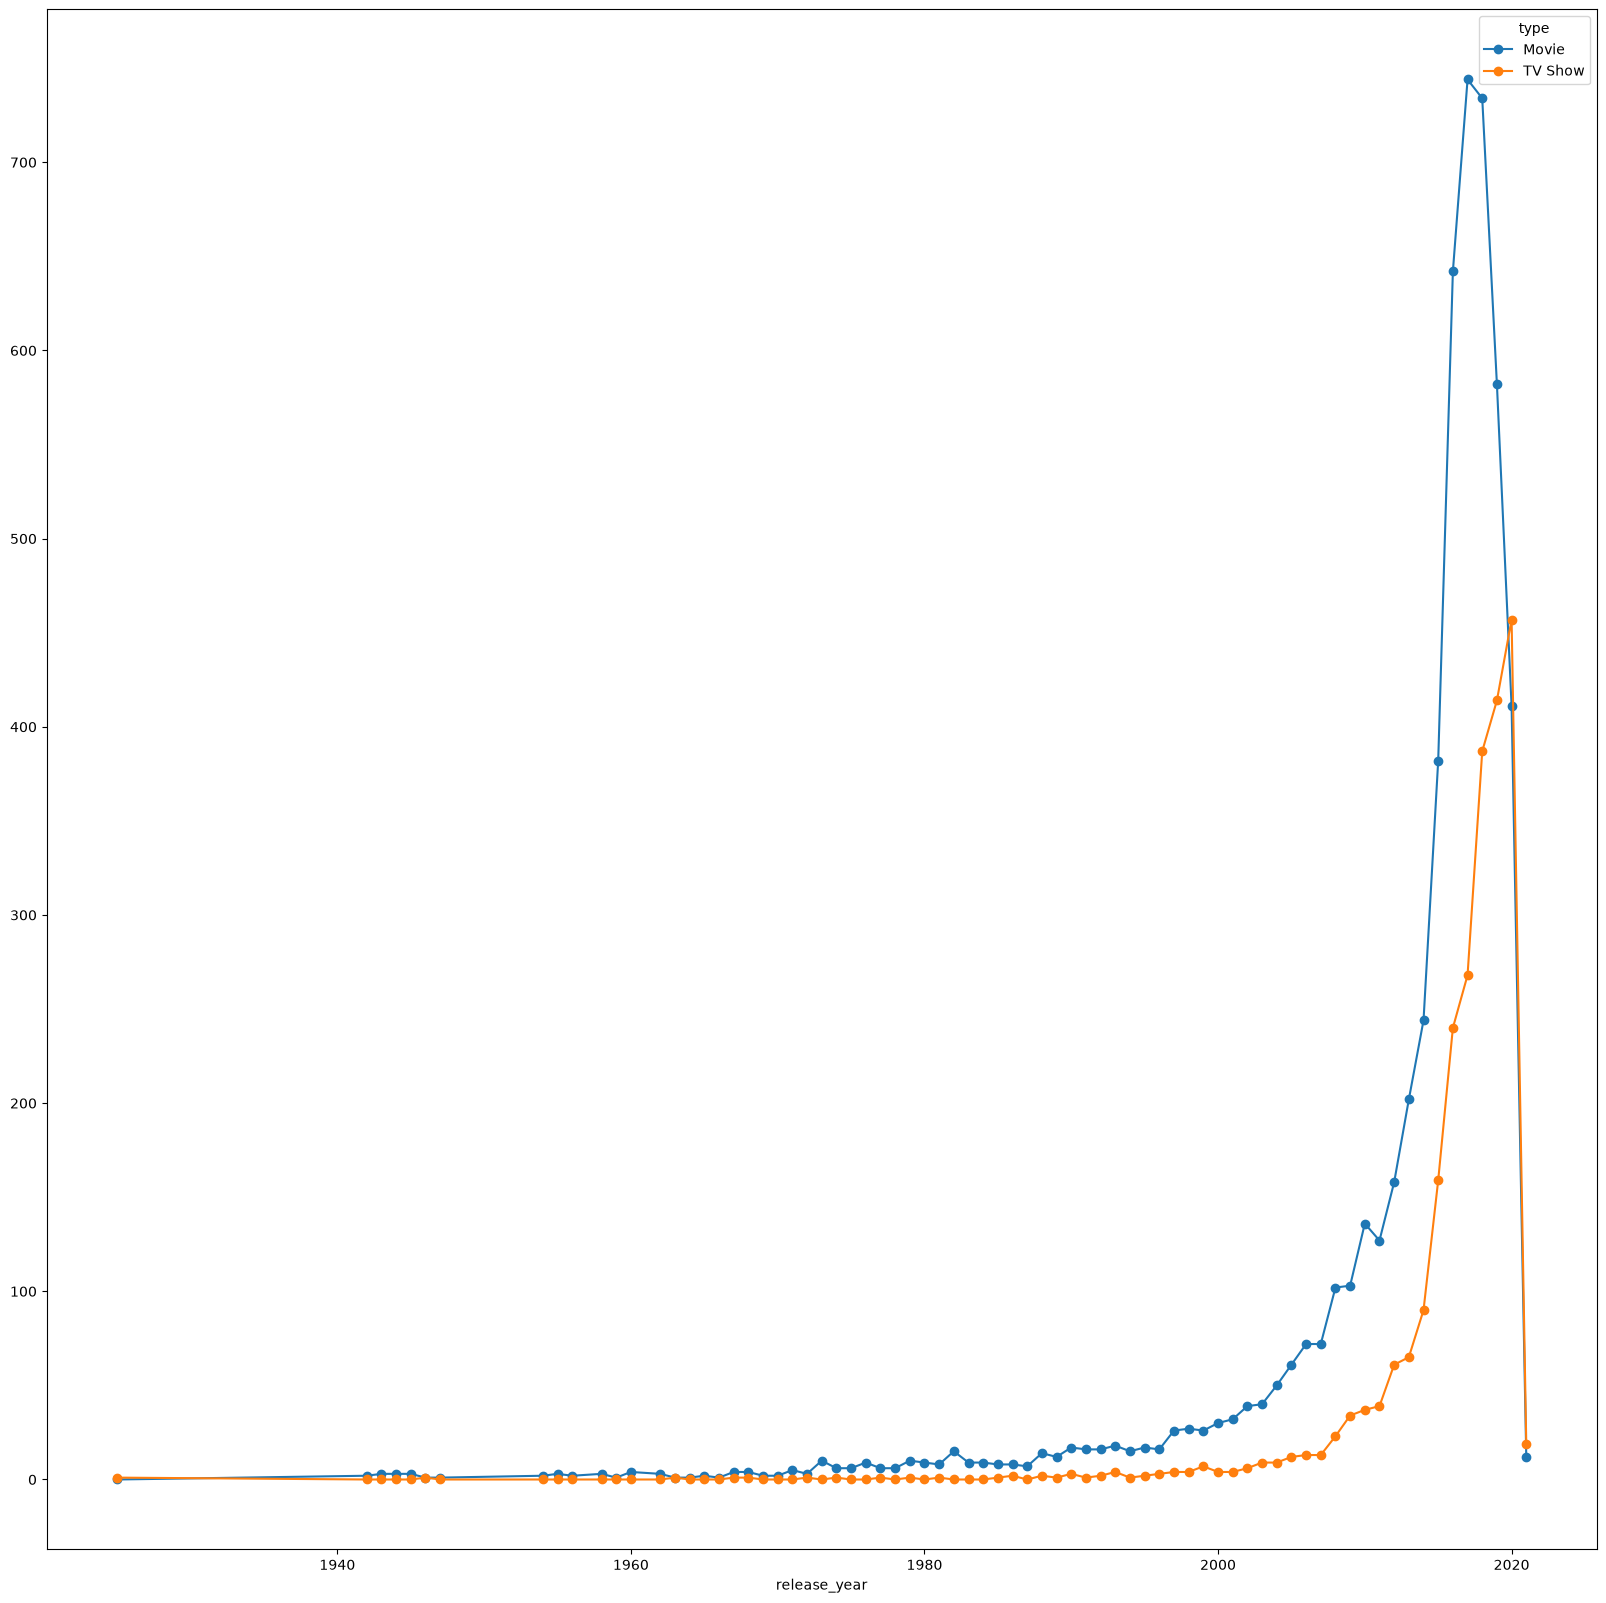

In [4]:
a=data[data.type=="Movie"].shape[0]
b=data[data.type=="TV Show"].shape[0]
data.groupby(["release_year","type"]).size().unstack(fill_value=0).plot(kind="line",figsize=(20,20),marker="o")

Text(0.5, 1.0, 'Top Genres Across Top Countries')

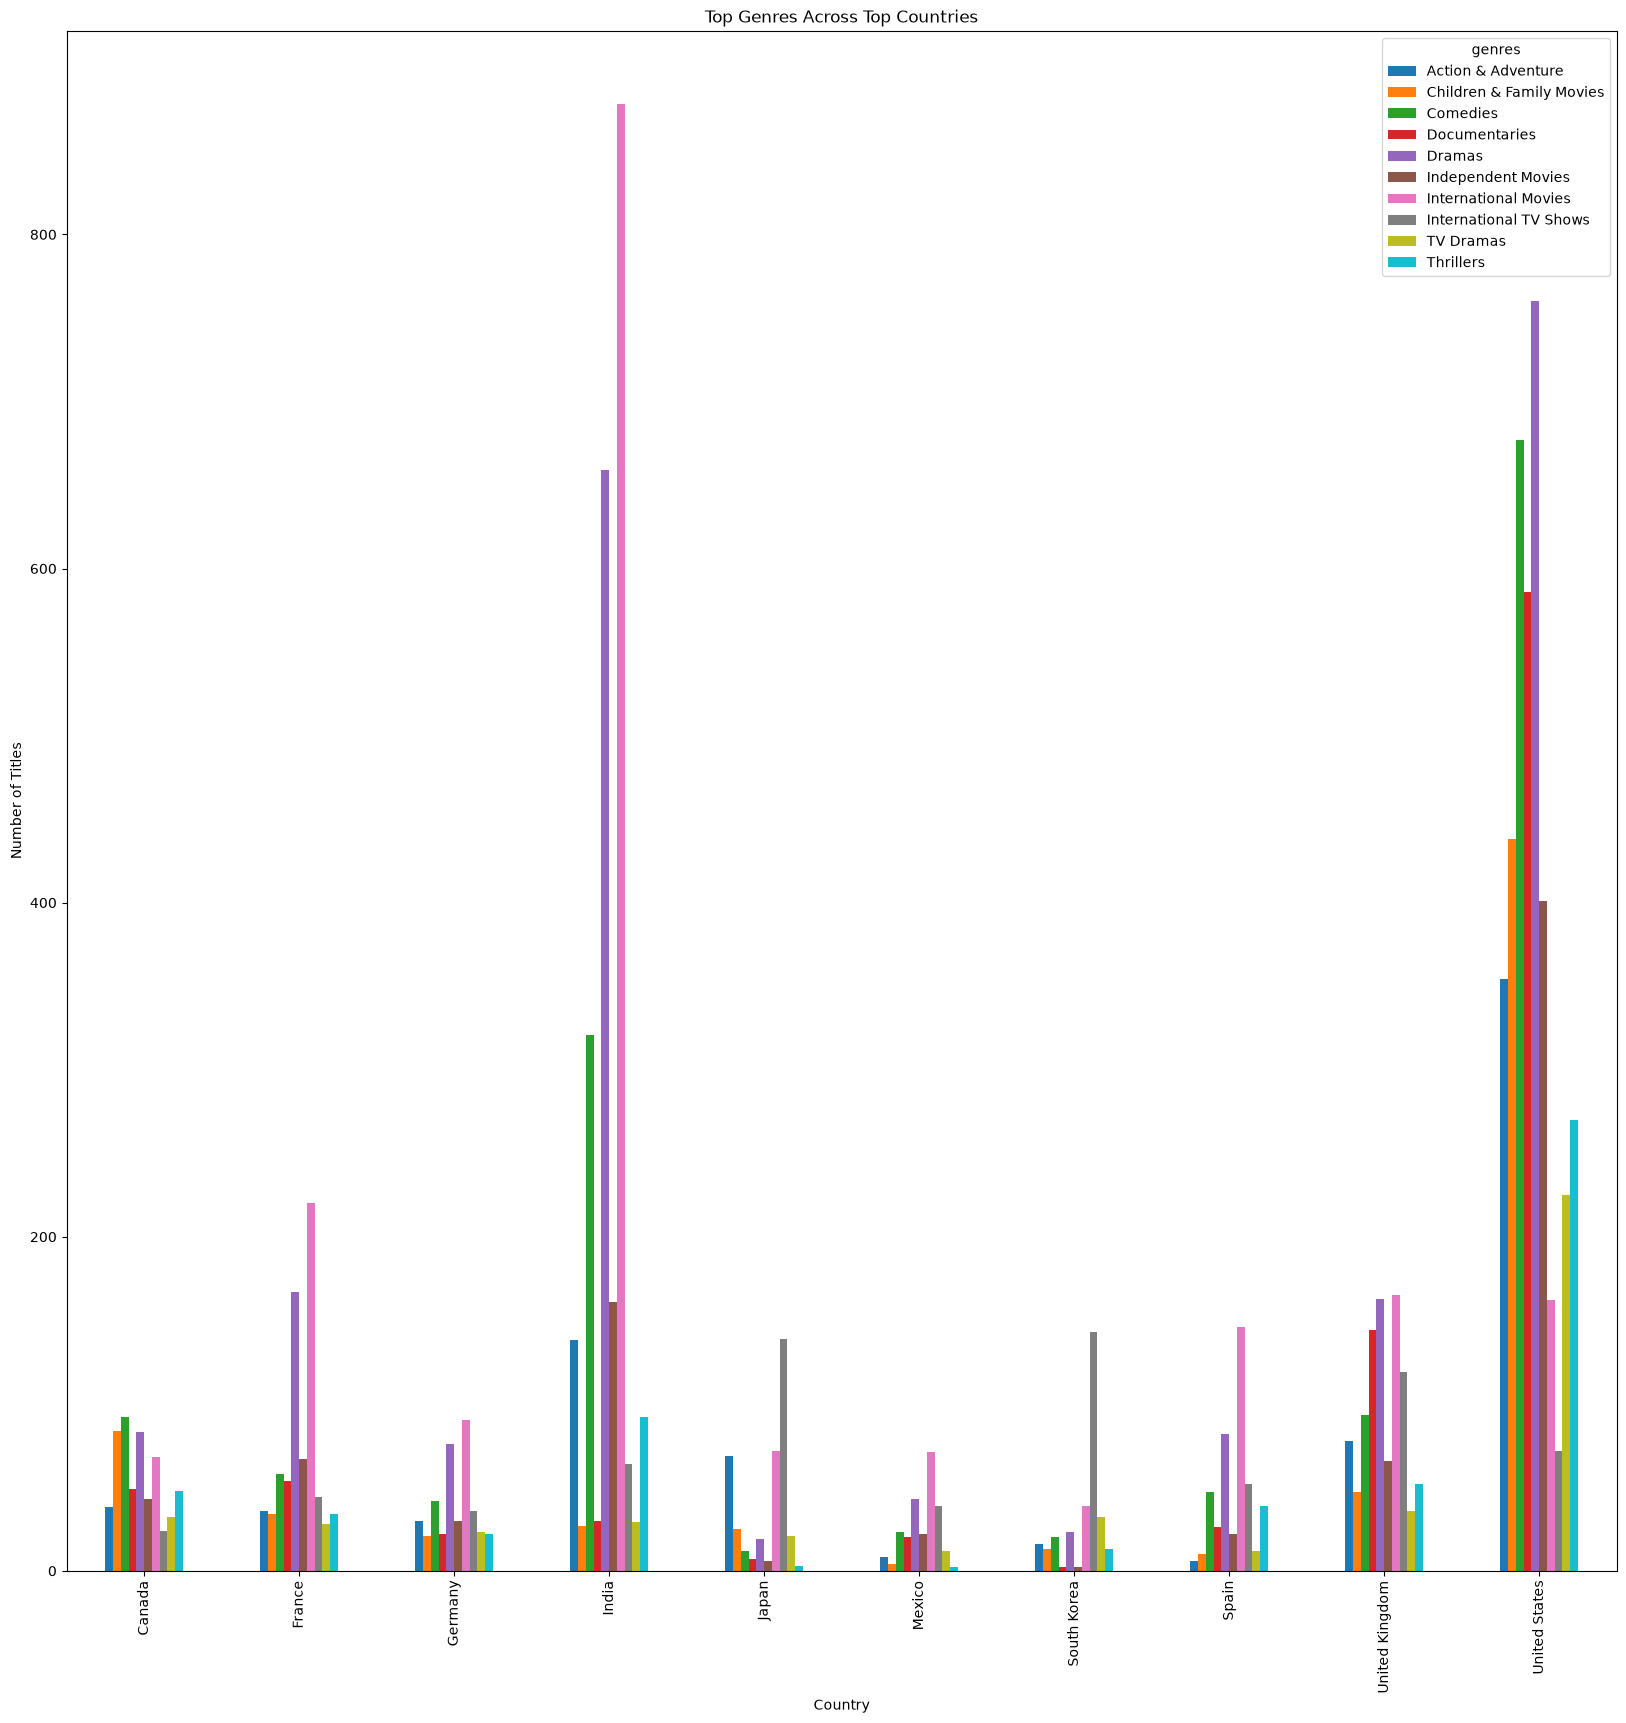

In [5]:
temp=data.copy()
temp = temp.assign(
    country=temp["country"].str.split(","),
    genres=temp["genres"].str.split(","),
    director=temp.director.str.split(",")
)
temp = temp.explode("country").explode("genres").explode("director")
temp["country"] = temp["country"].str.strip()
temp["genres"] = temp["genres"].str.strip()
temp["director"] = temp["director"].str.strip()

countries=temp.country.value_counts().head(10).index
genre=temp.genres.value_counts().head(10).index
one_director = temp.director.value_counts().head(12).index

ax=temp[temp.country.isin(countries) & temp.genres.isin(genre)].groupby(["country","genres"]).size().unstack(fill_value=0).plot(kind="bar",figsize=(20,20))

ax.set_xlabel("Country")
ax.set_ylabel("Number of Titles")
ax.set_title("Top Genres Across Top Countries")

<Axes: xlabel='country'>

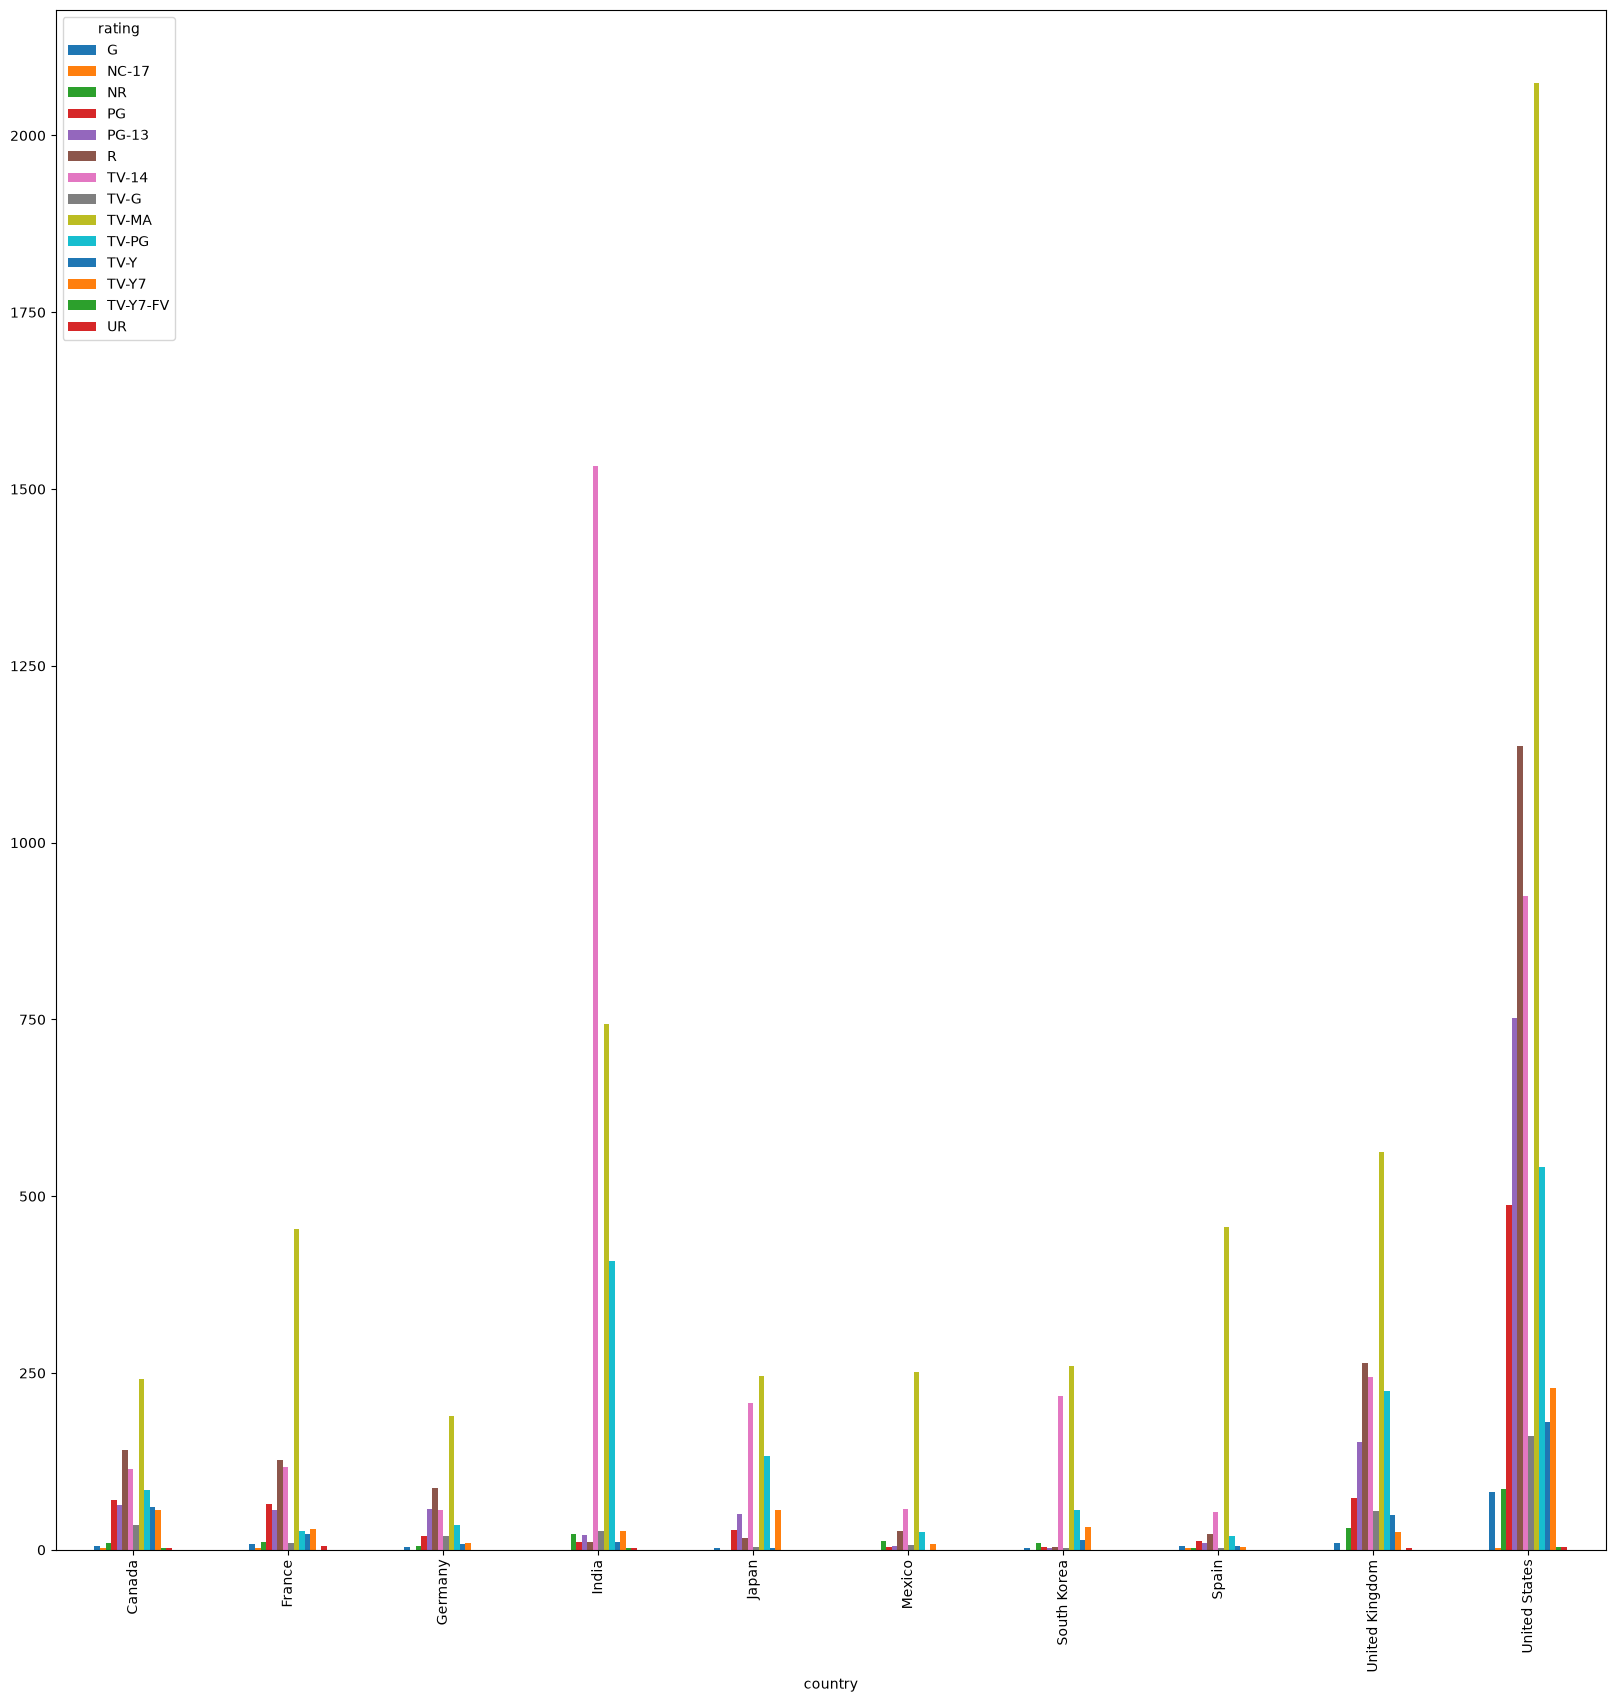

In [6]:
temp[temp.country.isin(countries)].groupby(["country","rating"]).size().unstack(fill_value=0).plot(kind="bar",figsize=(20,20))

<Axes: xlabel='genres'>

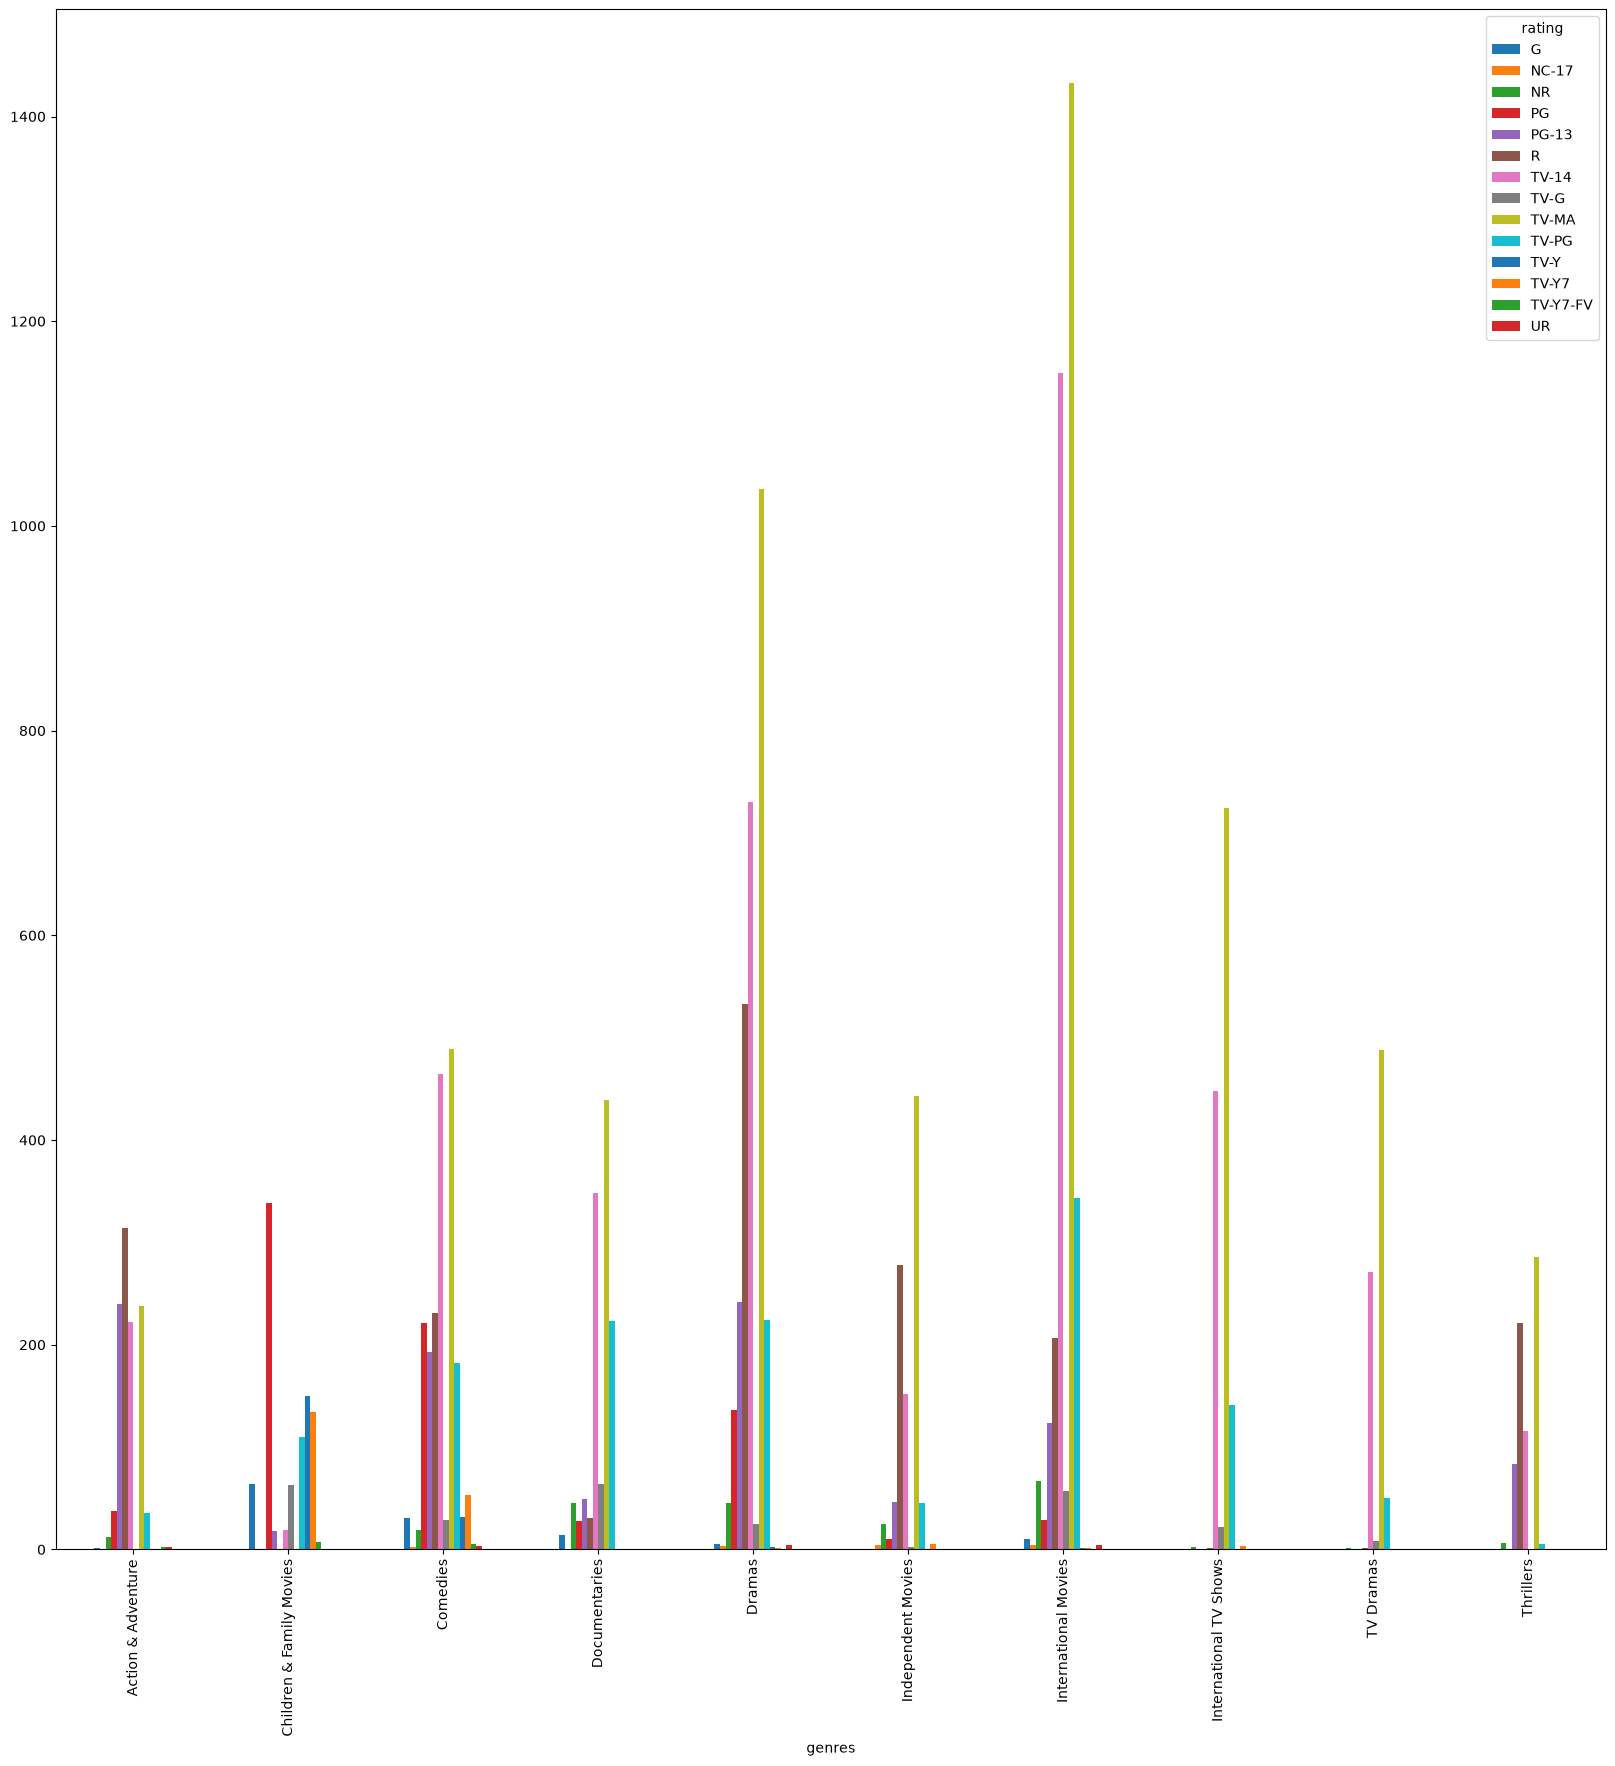

In [7]:
temp[temp.genres.isin(genre)].groupby(["genres","rating"]).size().unstack(fill_value=0).plot(kind="bar",figsize=(20,20))

<Axes: xlabel='director'>

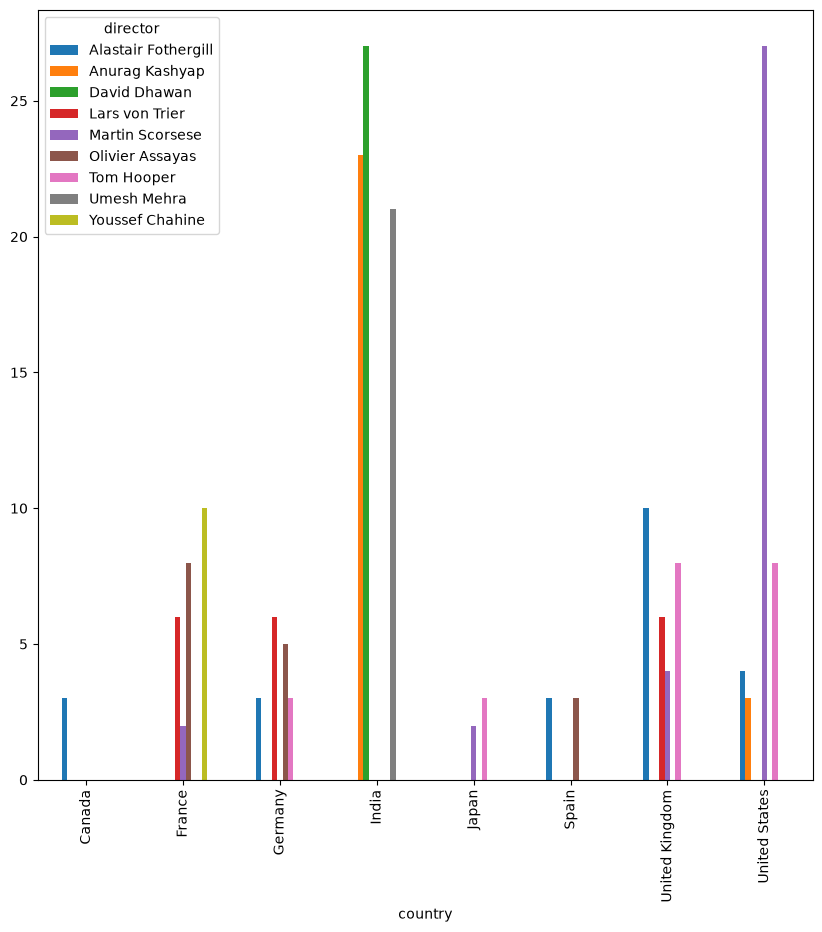

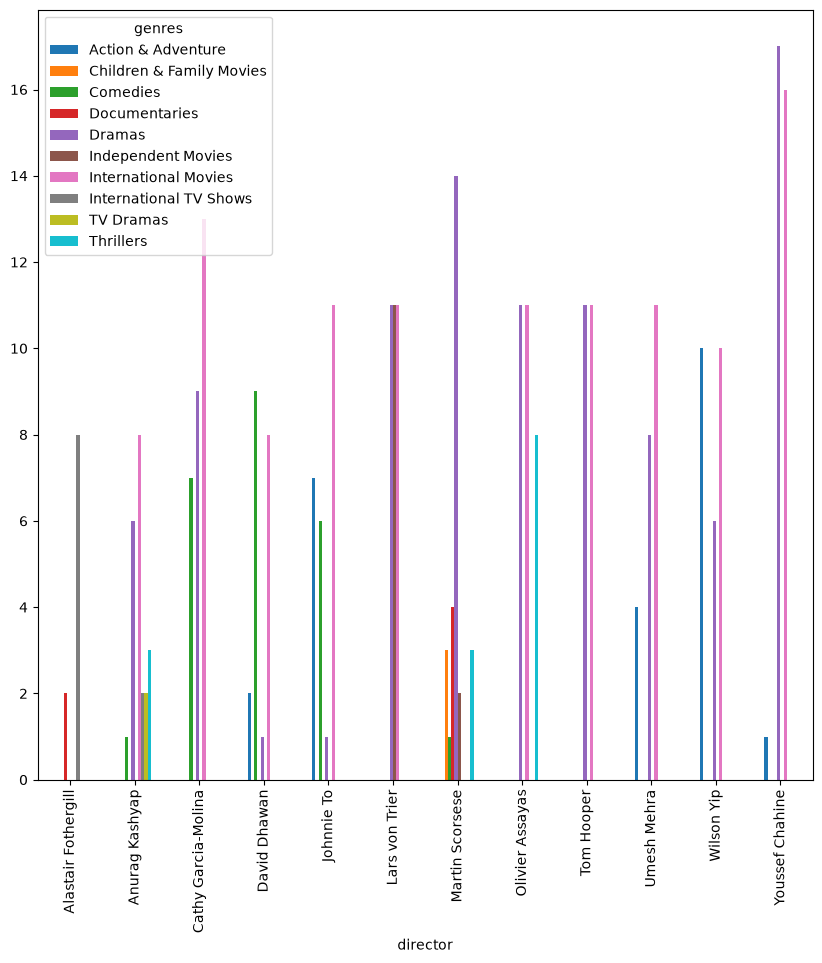

In [8]:
temp[temp.country.isin(countries) & temp.director.isin(one_director)].groupby(["country","director"]).size().unstack(fill_value=0).plot(kind="bar",figsize=(10,10))
temp[temp.genres.isin(genre) & temp.director.isin(one_director)].groupby(["director","genres"]).size().unstack(fill_value=0).plot(kind="bar",figsize=(10,10))

<Axes: xlabel='release_year'>

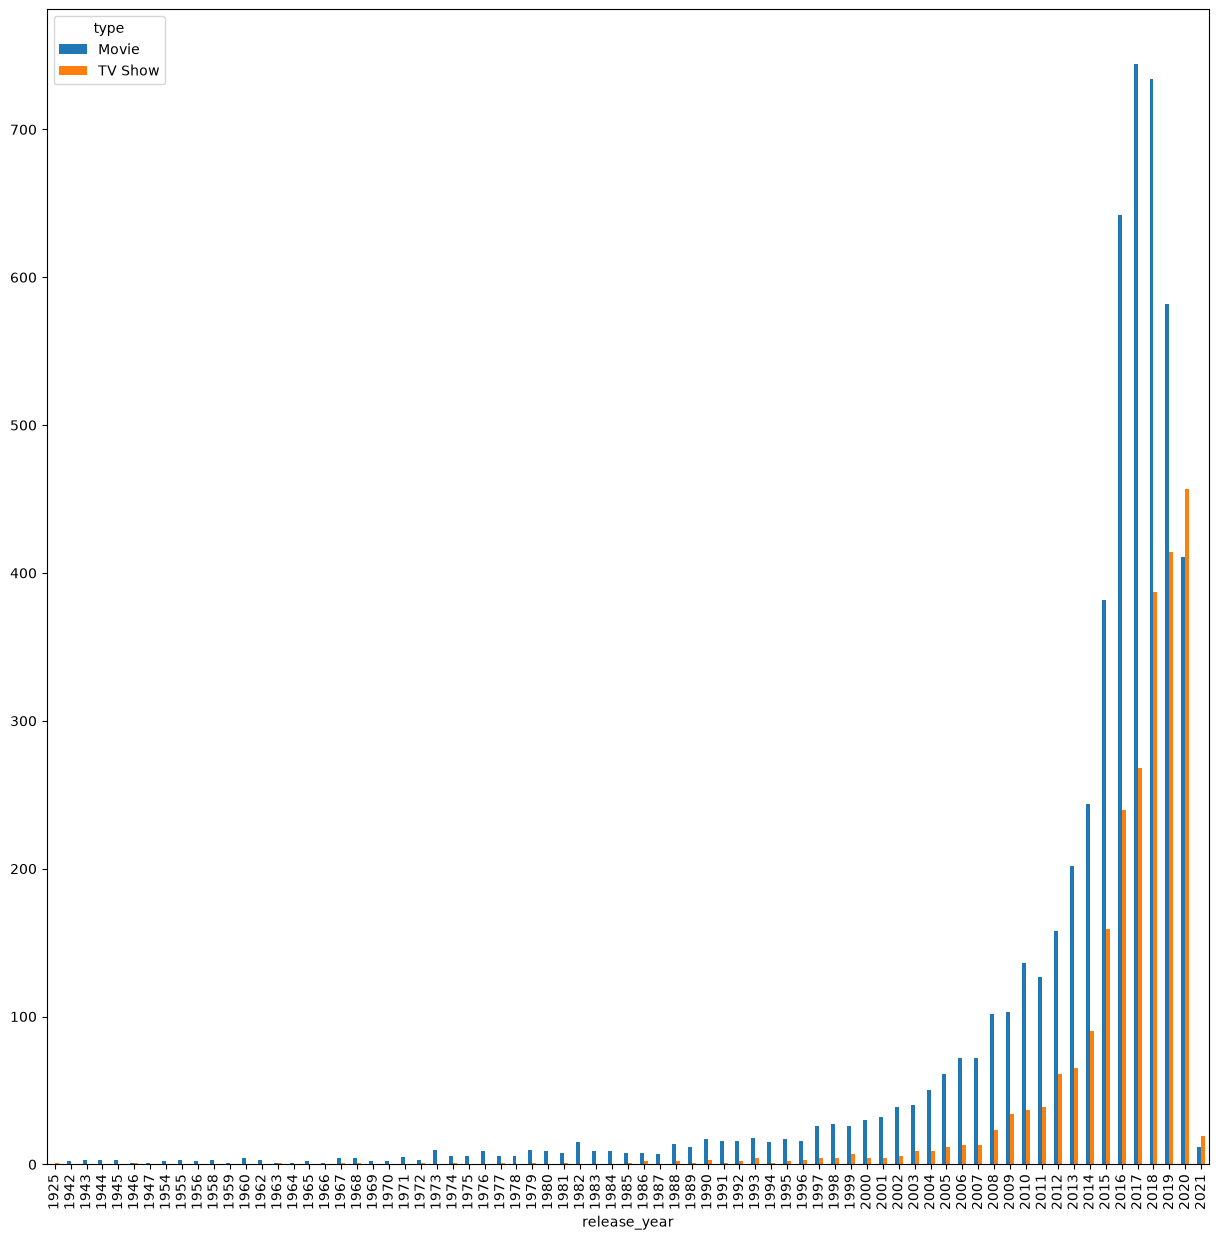

In [9]:
data.groupby(["release_year","type"]).size().unstack(fill_value=0).plot(kind="bar",figsize=(15,15))

### Section 10: Business Questions 

1.

Which country has produced the highest number of Action movies?

2.

Which year saw the largest increase in Netflix content?

3.

Are TV Shows becoming more common over time?

4.

What are the most popular genres in India?

5.

Which directors have worked across the widest variety of genres?

6.

What are the top 5 countries for TV Shows?

7.

Do older movies have different ratings than newer ones?

8.

How many titles were added to Netflix each month?

9.

Which decade has the highest number of releases?

10.

Which genre has grown the fastest over the years?

In [10]:
temp.loc[    (temp["type"] == "Movie") &   (temp["genres"] == "Action & Adventure"),   "country"].shape[0]
# temp.genres.value_counts()

1105

In [11]:
yearly=data["release_year"].value_counts().sort_index()
diff_=yearly.diff()
diff_.sort_values(ascending=False).head(1)

release_year
2016    341.0
Name: count, dtype: float64

<Axes: xlabel='release_year'>

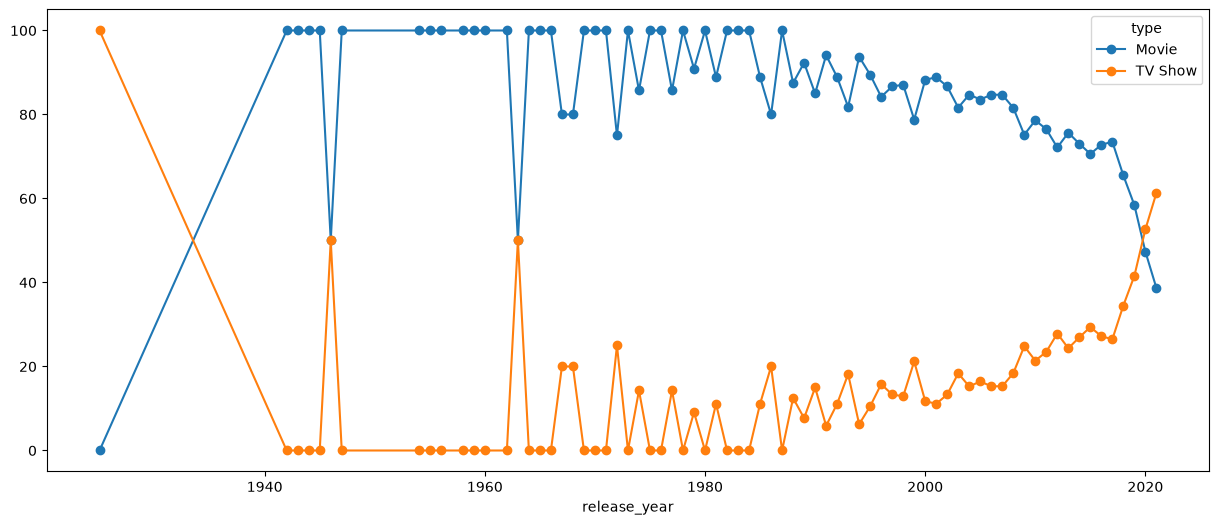

In [12]:
# data.loc[data.type=="TV Show","release_year"].value_counts().sort_index().plot(kind="bar",figsize=(15,15))
# data.groupby(["release_year","type"]).size().unstack(fill_value=0).plot(kind="line",figsize=(15,15) , marker="o" )

year_type=data.groupby(["release_year","type"]).size().unstack(fill_value=0)
(year_type.div(year_type.sum(axis=1), axis=0) * 100).plot(
    kind="line",
    figsize=(15,6),
    marker="o"
)

<Axes: >

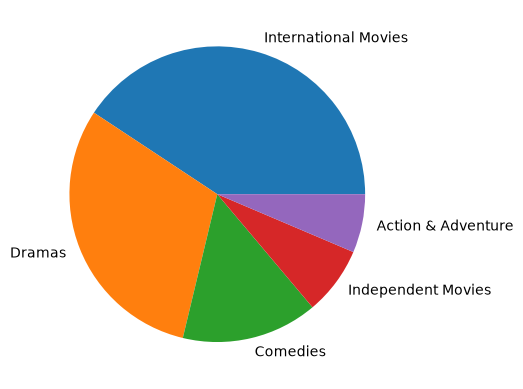

In [13]:
temp.loc[temp.country=="India","genres"].value_counts().head(5)
temp.loc[temp.country=="India","genres"].value_counts().head(5).plot(kind="pie")

<Axes: >

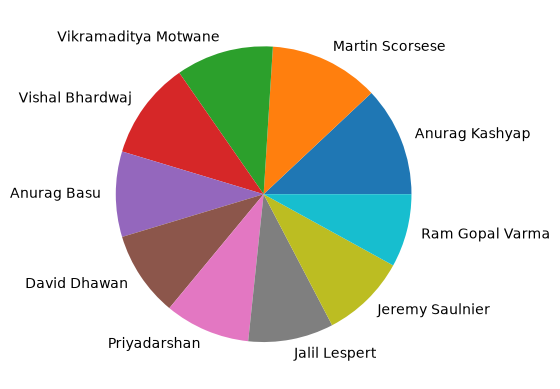

In [14]:
temp.groupby("director")["genres"].nunique().sort_values(ascending=False).head(10).plot(kind="pie")

In [15]:
temp.loc[temp.type=="TV Show","country"].value_counts().head(5)

country
United States     1660
United Kingdom     684
South Korea        461
Japan              406
Canada             246
Name: count, dtype: int64

<Axes: xlabel='release_year'>

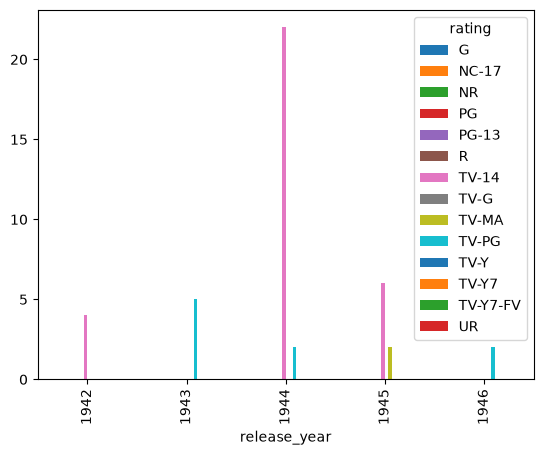

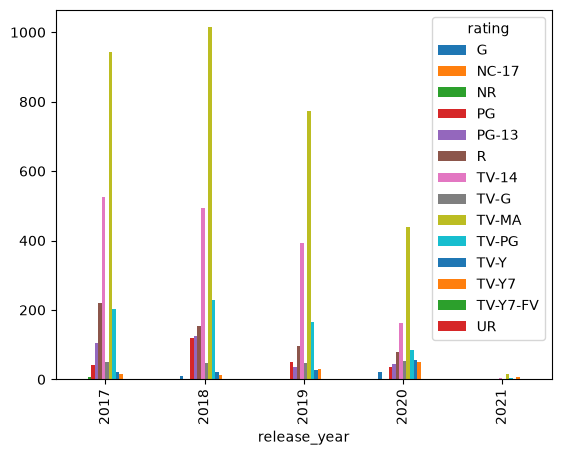

In [ ]:
# temp.loc[temp.type=="Movie","rating"].value_counts().head(5)
temp.loc[temp.type=="Movie",["rating","release_year"]].groupby(["release_year","rating"]).size().unstack(fill_value=0).head(5).plot(kind="bar")
temp.loc[temp.type=="Movie",["rating","release_year"]].groupby(["release_year","rating"]).size().unstack(fill_value=0).tail(5).plot(kind="bar")


In [49]:
data.head()
data.date_added.str.split("-").str[1].value_counts()

date_added
Dec    817
Oct    780
Jan    746
Nov    730
Mar    661
Sep    614
Aug    612
Apr    596
Jul    592
Jun    538
May    537
Feb    466
Name: count, dtype: int64

In [57]:

(data.release_year //10 * 10 ).value_counts().sort_index(ascending=False).head()

release_year
2020     899
2010    5711
2000     728
1990     225
1980     106
Name: count, dtype: int64

<Axes: xlabel='release_decade'>

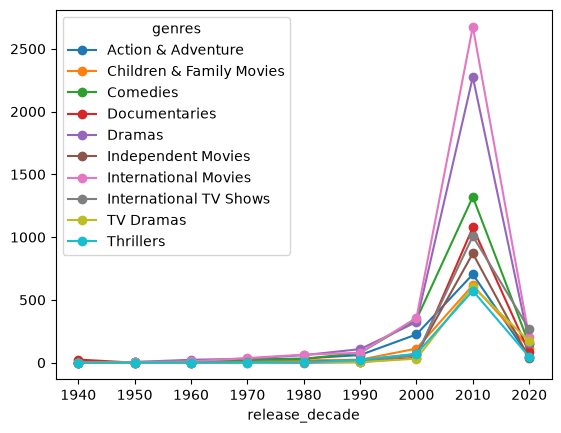

In [ ]:
temp["release_decade"]=(temp.release_year // 10) * 10
temp[temp.genres.isin(genre) ].groupby(["release_decade","genres"]).size().unstack(fill_value=0).plot(kind="line",marker="o")


### Section 11: Final Insights

-Movies account for a larger share of the catalog than TV Shows.

-The United States contributes the highest number of titles.

-Content production increased rapidly after 2015.

-Drama , Comedy , Documentaries and Action&Adventure are among the most common genres.

-A small number of directors contribute multiple titles, while many appear only once.

-Drama and International Movies show the strongest upward trend over time, indicating they have grown the fastest.